In [5]:
#Load necessary libraries
import numpy as np
import recurrence as rec
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.integrate import solve_ivp
import pandas as pd

# we can use the pyunicorn classes for all types of recurrence plots for convenience
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot
from pyunicorn.timeseries.cross_recurrence_plot import CrossRecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot

# Summary
The document is divided into two parts. 

In the first one, I compute a mutually coupled Roessler system in phase synchronization (PS) following Marwan (2007, p. 290). As a result, two `.csv` files are produces with the time series of the system.

In the second part, I explore the influence of the coupling parameter $\mu$ on the phase synchronization. This is done by measuring the CPR of the coupled system for different values of $\mu$. At the end, a graph is presented that shows ...

With this, you can tweak the phase synchronization from the model in the first part (by replacing the value of the variable `mu`) to get the amount of phase synchronization you desire. 

*NOTE: Also save the `recurrence.py` folder with the auxiliary functions in the same folder you're saving this file to be able to run it*

Some auxiliary functions we'll need.

In [151]:

#Recurrence matrix updated version
def recurrence_matrix(timeseries, epsilon, transpose = False):

    if timeseries.ndim == 1:
        r_matrix = []
        for i in range(len(timeseries)):
            current_row = []
            for j in range(len(timeseries)):
                current_value = np.abs(timeseries[i] - timeseries[j])
                if current_value <= epsilon:
                    current_row.append(1)
                else:
                    current_row.append(0)
        
            r_matrix.append(current_row)
    
        return np.array(r_matrix)
    
    else: 
        '''
        We will use euclidean distance in order to estimate neighbours.
        '''
        #Create distance matrix
        if transpose == True:
            timeseries = timeseries.T

        d_matrix = squareform(pdist(timeseries, metric = 'euclidean'))

        return d_matrix <= epsilon
    
#Find epsilon
def optimal_epsilon(timeseries, rrate, transpose = False):
    #1-dimensional time series
    if timeseries.ndim == 1:
        d_matrix = []
        for i in range(len(timeseries)):
            current_row = []
            for j in range(len(timeseries)):
                current_value = np.abs(timeseries[i] - timeseries[j])
                current_row.append(current_value)  
            d_matrix.append(current_row)
    
        d_matrix = np.array(d_matrix)

    # N-dimensional time series (N>1)
    else:
        #Create distance matrix
        if transpose == True:
            timeseries = timeseries.T

        d_matrix = squareform(pdist(timeseries, metric = 'euclidean'))
    #Colapse distance matrices and sort its values
    d_vector = d_matrix.flatten()

    #Sort values
    d_vector= np.sort(d_vector)

    n = int(len(d_vector)*rrate)

    return d_vector[n]

## Part 1
#### Mutually coupled Roessler systems

We begin by defining the function of the mutually coupled Roessler system. With it, we solve it using `scipy.integrate`

In [4]:
#Mutually coupled Roessler systems
#taken from Marwan (2007), eqs. A.9 and A.10
def coupled_Roessler(t, X, a, b, c, nu, mu):
    """
    X is a flattened vector [x1, x2, x3, y1, y2, y3].
    x corresponds to the first system, y corresponds to the 
    second one. 
    """
    dX = np.zeros(len(X))

    #First system (A.9)
    dX[0] = -(1 + nu)*X[1] - X[2]
    dX[1] = (1 + nu)*X[0] + a*X[1] + mu*(X[4] - X[1])
    dX[2] = b + X[2]*(X[0] - c)

    #Second system (A.10)
    dX[3] = -(1 - nu)*X[4] - X[5]
    dX[4] = (1 - nu)*X[3] + a*X[4] + mu*(X[1] - X[4])
    dX[5] = b + X[5]*(X[3] - c)

    return dX

In [153]:
# Parametres phase coherent regime
# Marwan (2007, p. 290)


a, b, c = 0.16, 0.1, 8.5
#a, b, c = 0.2, 0.2, 5.7
nu = 0.02
mu = 0.05


"""
a, b, c = 0.2925, 0.1, 8.5
nu = 0.02
mu = 0.2
"""

#Timestep and length not specified in paper
"""
1000 time steps was to short to show behaviour. We let it stabilize
for 5000 timesteps and use the remaining 10000
"""
T = 15000*0.02  #
dt = 0.02 #Bigger dt gave too rough of a plot
#dt = 0.04 #Bigger dt gave too rough of a plot

In [154]:
# Numerically Integrate The System States
#Initial conditions not specified
X0 = [0,0,0,0,0,0]

t_span = (0, T)
t_eval = np.arange(0, T, dt)

sol = solve_ivp(coupled_Roessler, t_span, X0, t_eval=t_eval, args=(a, b, c, nu, mu), method="RK45")

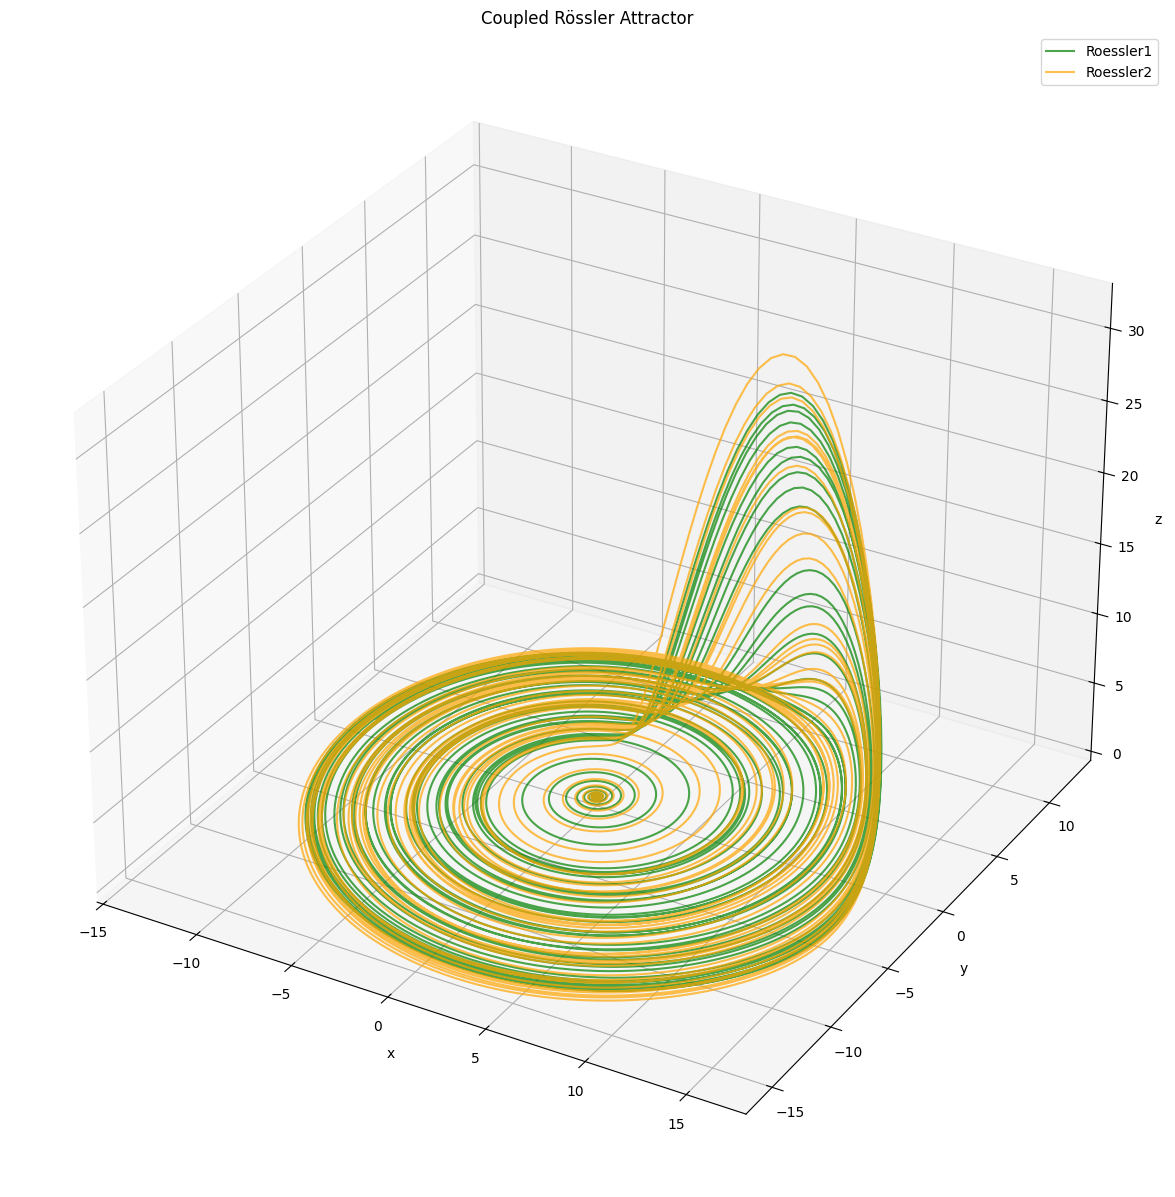

In [156]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

ax.plot(sol.y[0], sol.y[1], sol.y[2], alpha=0.7, label = 'Roessler1', color = 'green')
ax.plot(sol.y[3], sol.y[4], sol.y[5], alpha=0.7, label = 'Roessler2', color = 'orange')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
ax.set_title(f"Coupled Rössler Attractor")

plt.show()

Now we have our mutually coupled Roessler systems. First, we will check that they are in phase synchronization by computing their CPR. We'll then save the two time series as `.csv`.

In [157]:
#Separate models
R1_ts = sol.y[:3].T
R2_ts = sol.y[3:].T

#Get model after 5000 time steps
#R1_ts = R1_ts[5000:]
#R2_ts = R2_ts[5000:]
R1_ts = R1_ts[10000:]
R2_ts = R2_ts[10000:]

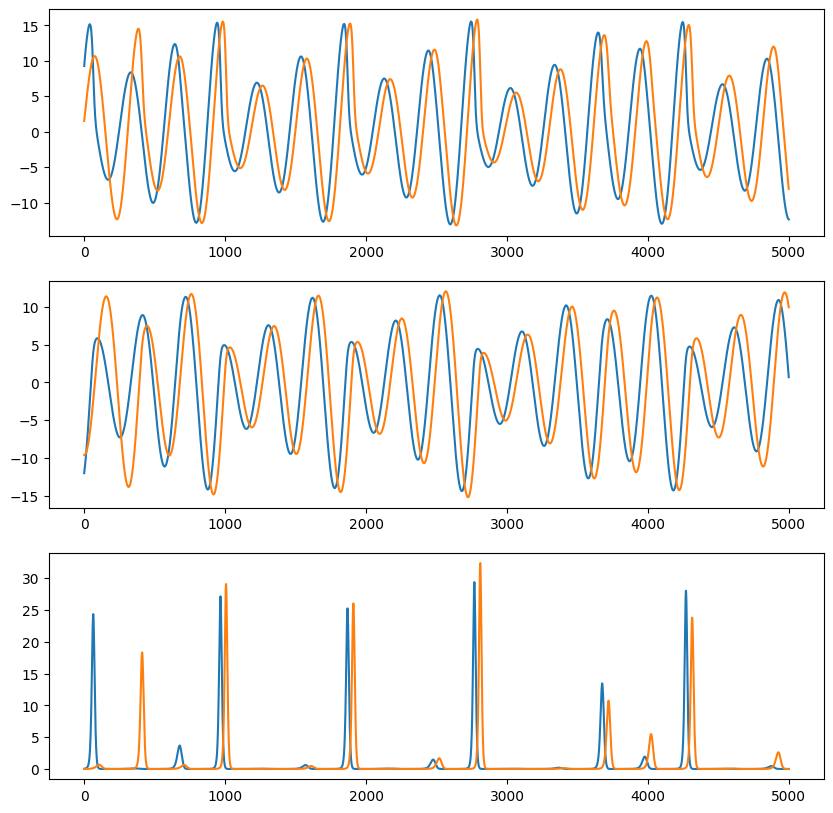

In [158]:
#Visualize
fig, axs = plt.subplots(3,1,figsize=(10, 10))

#Plot
axs[0].plot(R1_ts.T[0], label = '1')
axs[0].plot(R2_ts.T[0], label = '2')

axs[1].plot(R1_ts.T[1], label = '1')
axs[1].plot(R2_ts.T[1], label = '2')

axs[2].plot(R1_ts.T[2], label = '1')
axs[2].plot(R2_ts.T[2], label = '2')


plt.show()

We check PS with recurrence plots using a recurrence rate of 0.06.

In [159]:
eps_1 = optimal_epsilon(R1_ts,0.1)
eps_2 = optimal_epsilon(R2_ts,0.1)

In [160]:
rec_1 = recurrence_matrix(R1_ts,eps_1)
rec_2 = recurrence_matrix(R2_ts,eps_2)

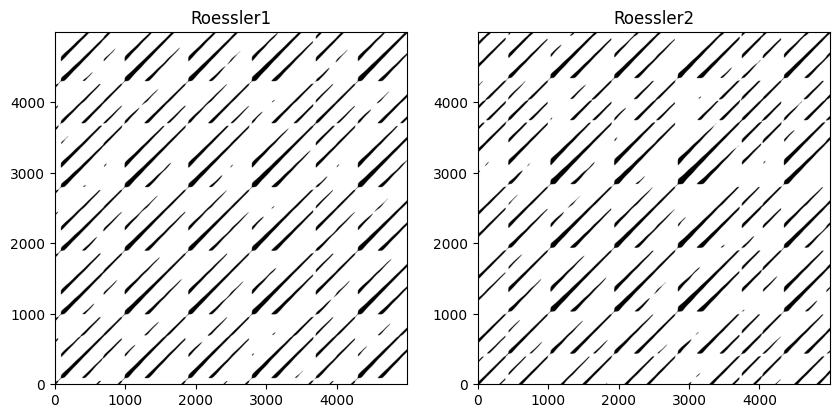

In [161]:
#Visualize
fig, axs = plt.subplots(1,2,figsize=(10, 10))

#Plot
axs[0].imshow(rec_1, origin='lower', cmap = 'binary')
axs[0].set_title('Roessler1')

axs[1].imshow(rec_2, origin='lower', cmap = 'binary')
axs[1].set_title('Roessler2')


plt.show()

Check $RR_{\tau}$ just to be sure

In [162]:
tau_rr_1 = rec.tau_recurrence(rec_1)
tau_rr_2 = rec.tau_recurrence(rec_2)

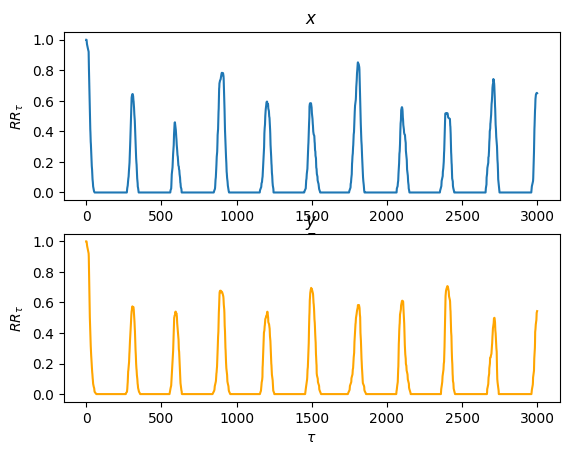

In [163]:
fig, ax = plt.subplots(2,1)   


ax[0].plot(np.arange(0,3000,1),tau_rr_1[:3000])
ax[0].set_title(r'$x$')
ax[0].set_ylabel(r'$RR_{\tau}$')
ax[0].set_xlabel(r'$\tau$')
ax[1].plot(np.arange(0,3000,1),tau_rr_2[:3000], color = 'orange')
ax[1].set_title(r'$y$')
ax[1].set_ylabel(r'$RR_{\tau}$')
ax[1].set_xlabel(r'$\tau$')

plt.show() 

In [164]:
print(rec.cpr(rec_1,rec_2))

0.776199613196836


They are in PS :)

Let's save it then.

In [ ]:
# convert arrays into dataframe
#DF1 = pd.DataFrame(R1_ts)
#DF2 = pd.DataFrame(R2_ts)

# save the dataframe as a csv file
#DF1.to_csv("PS_Roessler1.csv", index=False)
#DF2.to_csv("PS_Roessler2.csv", index=False)

## Part 2
#### Exploration of the coupling parameter
We now repeat a similar process from the one we just did. However, instead of computing the CPR of just one system to check if it's in phase synchronization, we'll compute the CPR of a set of systems while varying the coupling parameter $\mu$ (or `mu` in the code). With this, we want to show for which coupling parameters we have phase synchronization. 

**WARNING**

Due to the amount of values for the coupling parameter tested, the code takes really long to run. For working purposes you only need the information of the final graph (CPR vs. Coupling strength), so I advice you not to run this part and only use the information in the already computed graph. 

In [166]:
#Define list of coupling parameters from 0 to 0.12
coupling_mu = np.arange(0,0.12,0.005)

In [167]:
# Numerically integrate the system varying the coupling_mu values
sol_varied_coupling = [solve_ivp(coupled_Roessler, t_span, X0, t_eval=t_eval, args=(a, b, c, nu, coupling_mu[i]), method="RK45") for i in range(len(coupling_mu))]

In [168]:
#Separate models
R1_ts_varied_coupling = [sol_varied_coupling[i].y[:3].T for i in range(len(sol_varied_coupling))]
R2_ts_varied_coupling = [sol_varied_coupling[i].y[3:].T for i in range(len(sol_varied_coupling))]

#Get models after 5000 time steps
R1_ts_varied_coupling = [R1_ts_varied_coupling[i][5000:] for i in range(len(R1_ts_varied_coupling))]
R2_ts_varied_coupling = [R2_ts_varied_coupling[i][5000:] for i in range(len(R2_ts_varied_coupling))]

In [169]:
#Compute recurrence matrices (step 1)
rec1_varied_coupling = [RecurrencePlot(R1_ts_varied_coupling[i], recurrence_rate=0.05, metric="euclidean") for i in range(len(R1_ts_varied_coupling))]

rec2_varied_coupling = [RecurrencePlot(R2_ts_varied_coupling[i], recurrence_rate=0.05, metric="euclidean") for i in range(len(R2_ts_varied_coupling))]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance 

In [170]:
#Compute recurrence matrices (step 2)
rm_rec1_varied_coupling = [rec1_varied_coupling[i].recurrence_matrix() for i in range(len(rec1_varied_coupling))]
rm_rec2_varied_coupling = [rec2_varied_coupling[i].recurrence_matrix() for i in range(len(rec2_varied_coupling))]

In [171]:
#Save CPR values to see when we get PS
cpr_values = [rec.cpr(rm_rec1_varied_coupling[i],rm_rec2_varied_coupling[i]) for i in range(len(rm_rec1_varied_coupling))]

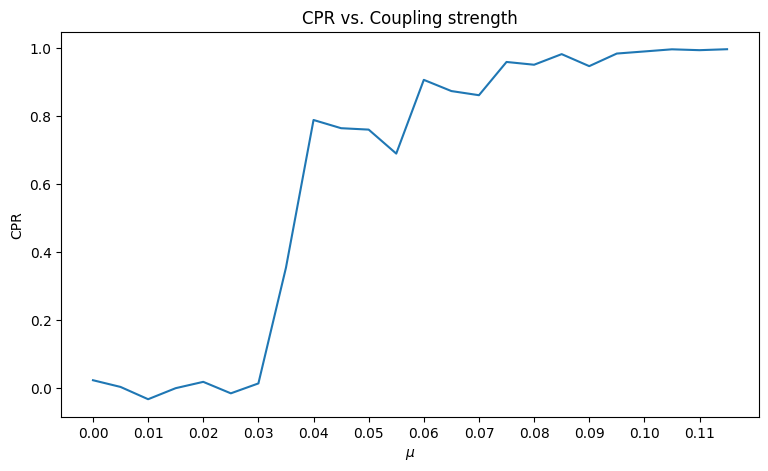

In [172]:
#Observe
fig, ax = plt.subplots(figsize=(9,5))   


ax.plot(coupling_mu,cpr_values)
ax.set_xticks(np.arange(0,0.12,0.01))
ax.set_title(r'CPR vs. Coupling strength')
ax.set_ylabel(r'CPR')
ax.set_xlabel(r'$\mu$')

plt.show() 

As can be seen, our coupled Roessler systems enter a phase synchronization regime for values of $\mu \geq 0.04$. 

In [1]:
# Parametres phase coherent regime
# Marwan (2007, p. 290)

#Synched ts

a, b, c = 0.16, 0.1, 8.5
#a, b, c = 0.2, 0.2, 5.7
nu = 0.02
mu = 0.06


"""
a, b, c = 0.2925, 0.1, 8.5
nu = 0.02
mu = 0.2
"""

#Timestep and length not specified in paper
"""
1000 time steps was to short to show behaviour. We let it stabilize
for 5000 timesteps and use the remaining 10000
"""
T = 15000*0.02  #
dt = 0.02 #Bigger dt gave too rough of a plot
#dt = 0.04 #Bigger dt gave too rough of a plot

In [6]:
# Numerically Integrate The System States
#Initial conditions not specified
X0 = [0,0,0,0,0,0]

t_span = (0, T)
t_eval = np.arange(0, T, dt)

sol = solve_ivp(coupled_Roessler, t_span, X0, t_eval=t_eval, args=(a, b, c, nu, mu), method="RK45")

In [7]:
#Separate models
synch1 = sol.y[:3].T
synch2 = sol.y[3:].T

#Get model after 10000 time steps
synch1= synch1[10000:]
synch2 = synch2[10000:]

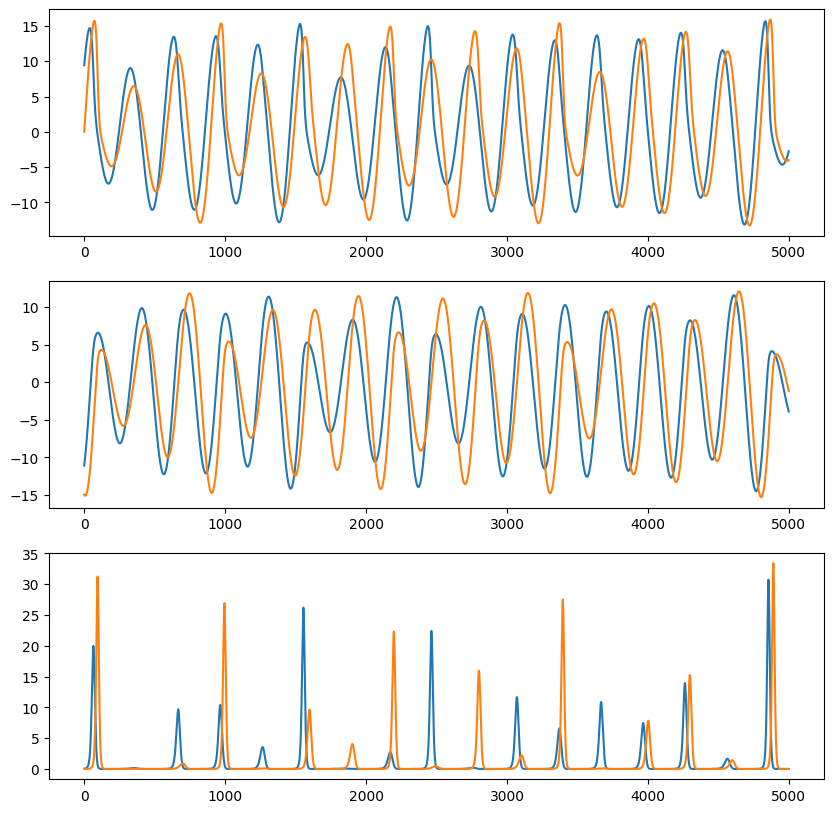

In [180]:
#Visualize
fig, axs = plt.subplots(3,1,figsize=(10, 10))

#Plot
axs[0].plot(synch1.T[0], label = '1')
axs[0].plot(synch2.T[0], label = '2')

axs[1].plot(synch1.T[1], label = '1')
axs[1].plot(synch2.T[1], label = '2')

axs[2].plot(synch1.T[2], label = '1')
axs[2].plot(synch2.T[2], label = '2')


plt.show()

Visually they seem in PS.

In [8]:
recx_synch = RecurrencePlot(synch1, metric="euclidean", recurrence_rate=0.1)
recy_synch = RecurrencePlot(synch2, metric="euclidean", recurrence_rate=0.1)

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


In [9]:
RX_synch = recx_synch.recurrence_matrix()
RY_synch = recy_synch.recurrence_matrix()

print(rec.cpr(RX_synch, RY_synch))

0.9276899827449323


In [13]:
px_synch = rec.tau_recurrence(RX_synch)
py_synch = rec.tau_recurrence(RY_synch)

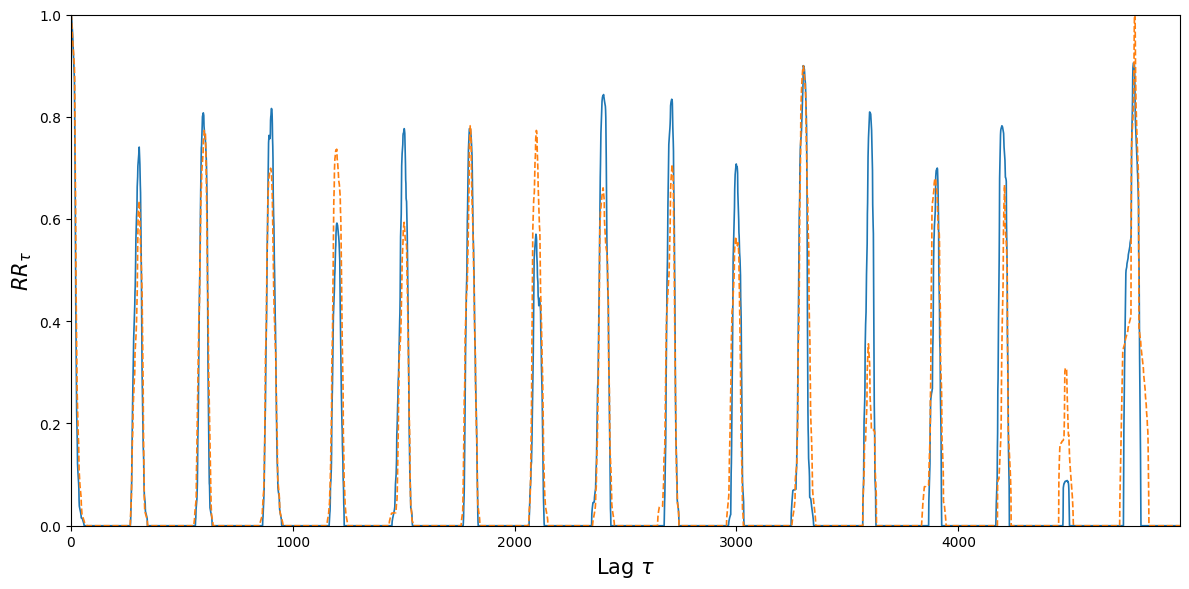

In [ ]:
# Visualize
fig, axs = plt.subplots(figsize=(12, 6))

taus = np.arange(0,len(px_synch))

# Plot each graph, and manually set the y tick values
axs.plot(taus, px_synch, linewidth = 1.2)
axs.plot(taus, py_synch, linestyle='dashed', linewidth = 1.2)

axs.margins(0) 

#axs.set_xticks(np.arange(0,len(tau_rr_embed),50))

axs.set_ylabel(r'$RR_{\tau}$', fontsize = 15)
axs.set_xlabel(r'Lag $\tau$', fontsize = 15)
#axs.set_title('Embedded time series')
plt.tight_layout()

plt.show()

#fig.savefig('RRT_PSSynch.png')

In [182]:
# convert arrays into dataframe
DF1 = pd.DataFrame(synch1)
DF2 = pd.DataFrame(synch2)

# save the dataframe as a csv file
DF1.to_csv("PS_synch1.csv", index=False)
DF2.to_csv("PS_synch2.csv", index=False)

In [21]:
#No synch
mu = 0.03

sol = solve_ivp(coupled_Roessler, t_span, X0, t_eval=t_eval, args=(a, b, c, nu, mu), method="RK45")

In [22]:
#Separate models
nosynch1 = sol.y[:3].T
nosynch2 = sol.y[3:].T

#Get model after 10000 time steps
nosynch1= nosynch1[10000:]
nosynch2 = nosynch2[10000:]

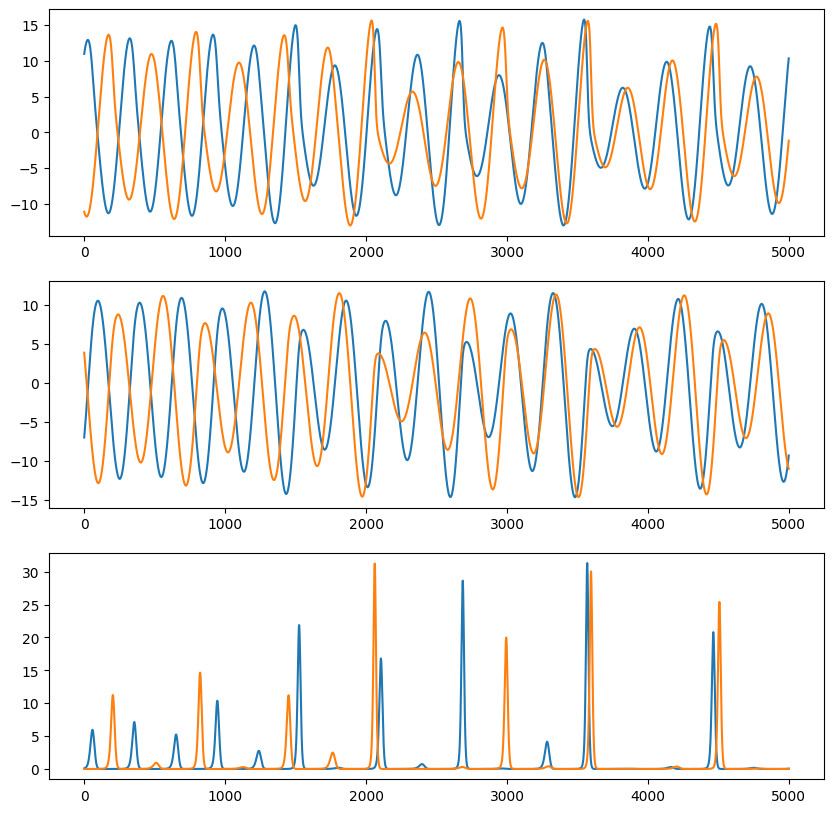

In [195]:
#Visualize
fig, axs = plt.subplots(3,1,figsize=(10, 10))

#Plot
axs[0].plot(nosynch1.T[0], label = '1')
axs[0].plot(nosynch2.T[0], label = '2')

axs[1].plot(nosynch1.T[1], label = '1')
axs[1].plot(nosynch2.T[1], label = '2')

axs[2].plot(nosynch1.T[2], label = '1')
axs[2].plot(nosynch2.T[2], label = '2')


plt.show()

It clearly seems out of PS.

In [23]:
RX_nosynch = RecurrencePlot(nosynch1, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()
RY_nosynch = RecurrencePlot(nosynch2, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

print(rec.cpr(RX_nosynch, RY_nosynch))

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
-0.10794046759669444


In [24]:
px_nosynch = rec.tau_recurrence(RX_nosynch)
py_nosynch = rec.tau_recurrence(RY_nosynch)

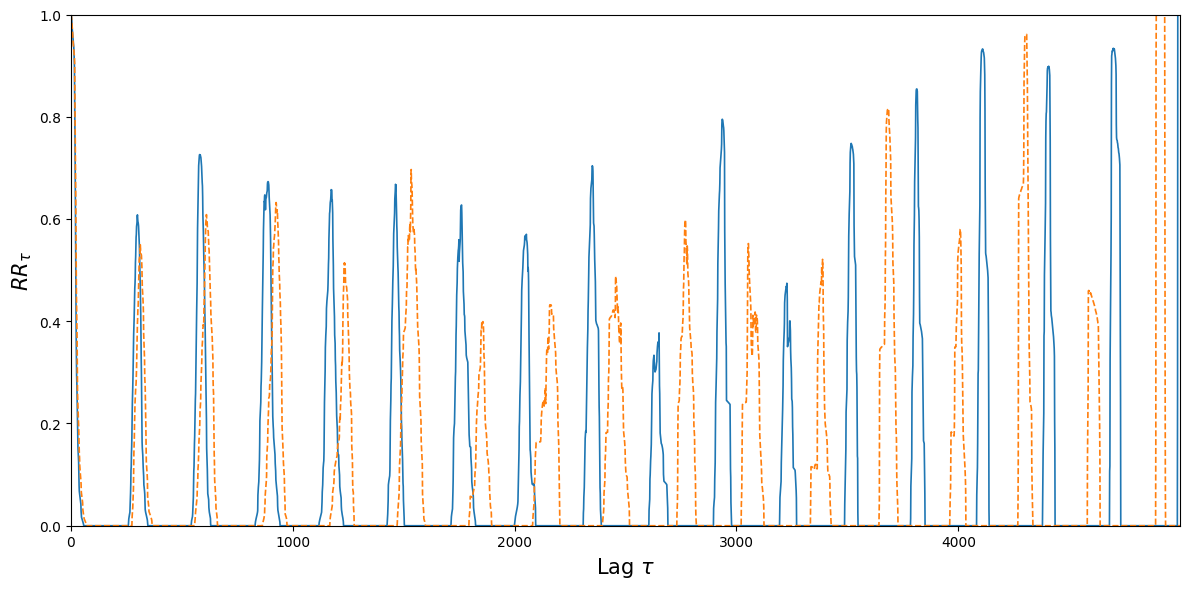

In [ ]:
# Visualize
fig, axs = plt.subplots(figsize=(12, 6))

taus = np.arange(0,len(px_nosynch))

# Plot each graph, and manually set the y tick values
axs.plot(taus, px_nosynch, linewidth = 1.2)
axs.plot(taus, py_nosynch, linestyle='dashed', linewidth = 1.2)

axs.margins(0) 

#axs.set_xticks(np.arange(0,len(tau_rr_embed),50))

axs.set_ylabel(r'$RR_{\tau}$', fontsize = 15)
axs.set_xlabel(r'Lag $\tau$', fontsize = 15)
#axs.set_title('Embedded time series')
plt.tight_layout()

plt.show()

#fig.savefig('RRT_PSNoSynch.png')

In [197]:
# convert arrays into dataframe
DF1 = pd.DataFrame(nosynch1)
DF2 = pd.DataFrame(nosynch2)

# save the dataframe as a csv file
DF1.to_csv("PS_nosynch1.csv", index=False)
DF2.to_csv("PS_nosynch2.csv", index=False)

In [27]:
import string

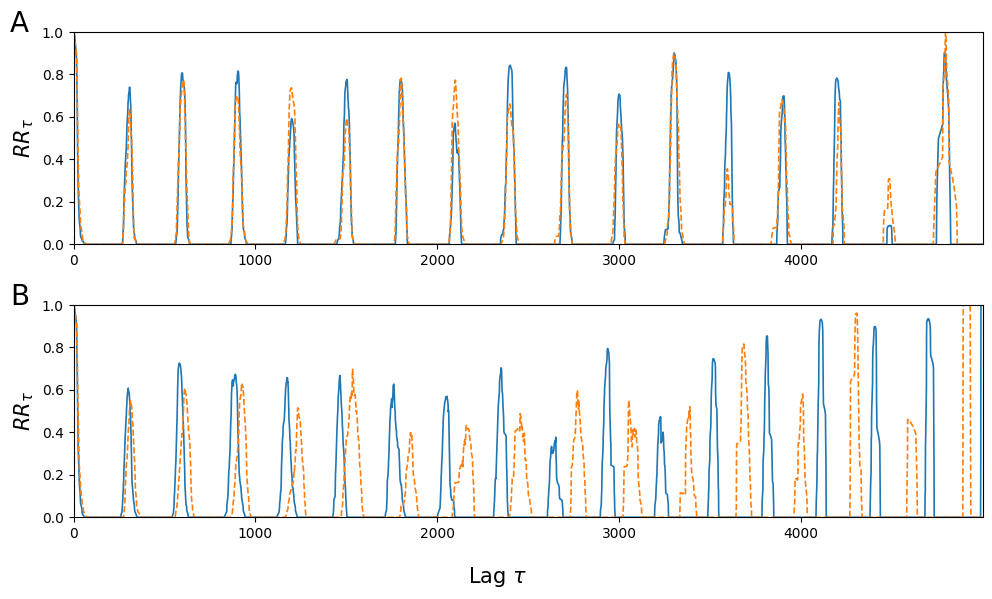

In [31]:
# Visualize
fig, axs = plt.subplots(2,1,figsize=(10, 6))

taus = np.arange(0,len(px_nosynch))

axs[0].plot(taus, px_synch, linewidth = 1.2)
axs[0].plot(taus, py_synch, linestyle='dashed', linewidth = 1.2)

axs[0].margins(0) 

#axs.set_xticks(np.arange(0,len(tau_rr_embed),50))

axs[0].set_ylabel(r'$RR_{\tau}$', fontsize = 15)
axs[0].text(-0.07, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

# Plot each graph, and manually set the y tick values
axs[1].plot(taus, px_nosynch, linewidth = 1.2)
axs[1].plot(taus, py_nosynch, linestyle='dashed', linewidth = 1.2)

axs[1].margins(0) 

#axs.set_xticks(np.arange(0,len(tau_rr_embed),50))

axs[1].set_ylabel(r'$RR_{\tau}$', fontsize = 15)
axs[1].text(-0.07, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)
#axs.set_title('Embedded time series')


fig.supxlabel(r'Lag $\tau$', fontsize = 15)

plt.tight_layout()

plt.show()

fig.savefig('RRT_PS.png')